# Topological Data Analysis with Optimized Wasserstein Metrics

This notebook implements TDA using the two most efficient Wasserstein distance implementations:
1. Regular Sinkhorn (reg=0.1)
2. Optimized Sinkhorn method (with PCA and parallelization)


In [1]:
import sys
from pathlib import Path
project_root = Path(__file__).resolve().parents[0] if '__file__' in globals() else Path().resolve().parents[0]
sys.path.insert(0, str(project_root))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm.notebook import tqdm

from tomato.utils import tomato_data_path
from tomato.metrics import (
    wasserstein_distances_sinkhorn,
    wasserstein_distances_optimized
)

import ripser
from ripser import Rips
from persim import plot_diagrams
import persim

## 1. Load and Prepare the Data

In [ ]:

df_enc = pd.read_parquet(tomato_data_path() / 'encoding_unif5k.parquet')
print(f"Loaded data shape: {df_enc.shape}")
print(f"Number of unique reviews: {df_enc['review_id'].nunique()}")

Loaded data shape: (31477, 771)
Number of unique reviews: 1000


In [ ]:
dim_cols = [c for c in df_enc.columns if c.startswith('dim_')]

mean_vectors = np.vstack(
    df_enc\
        .groupby('review_id')\
        .apply(lambda g: np.average(
            g[dim_cols].values, weights=g.attention_mask, axis=0))\
        .values)

## 2. Compute Distance Matrices with Both Methods



In [ ]:
def time_execution(func, *args, **kwargs):
    start_time = time.time()
    result = func(*args, **kwargs)
    end_time = time.time()
    return result, end_time - start_time

In [ ]:
print("Computing Wasserstein distances using regular Sinkhorn (reg=0.1)...")
distances_sinkhorn, time_sinkhorn = time_execution(
    wasserstein_distances_sinkhorn, 
    df_enc,
    reg=0.1
)
print(f"Completed in {time_sinkhorn:.2f} seconds")
print(f"Distance matrix shape: {distances_sinkhorn.shape}")

Computing Wasserstein distances using regular Sinkhorn (reg=0.1)...
Completed in 888.62 seconds
Distance matrix shape: (1000, 1000)


In [ ]:
print("Computing Wasserstein distances using optimized Sinkhorn...")
distances_optimized, time_optimized = time_execution(
    wasserstein_distances_optimized,
    df_enc,
    method='sinkhorn',
    parallel=True, 
    nCores=4,
    reg=0.1,
    pca_dim=64,
    batch_size=20
)
print(f"Completed in {time_optimized:.2f} seconds")
print(f"Distance matrix shape: {distances_optimized.shape}")
print(f"Speed improvement: {time_sinkhorn / time_optimized:.2f}x faster")

Computing Wasserstein distances using optimized Sinkhorn...


Sinkhorn Wasserstein Batches: 100%|██████████| 24975/24975 [04:28<00:00, 92.90it/s] 

Completed in 270.11 seconds
Distance matrix shape: (1000, 1000)


NameError: name 'time_sinkhorn' is not defined

## 3. Comparing the Distance Matrices

Let's check if the two distance matrices are highly correlated:

In [ ]:
n = distances_sinkhorn.shape[0]
idx_upper = np.triu_indices(n, k=1) 

sinkhorn_flat = distances_sinkhorn[idx_upper]
optimized_flat = distances_optimized[idx_upper]

correlation = np.corrcoef(sinkhorn_flat, optimized_flat)[0, 1]
mae = np.mean(np.abs(sinkhorn_flat - optimized_flat))

print(f"Correlation between distance matrices: {correlation:.4f}")
print(f"Mean absolute error: {mae:.4f}")

Correlation between distance matrices: 0.8219
Mean absolute error: 0.1122


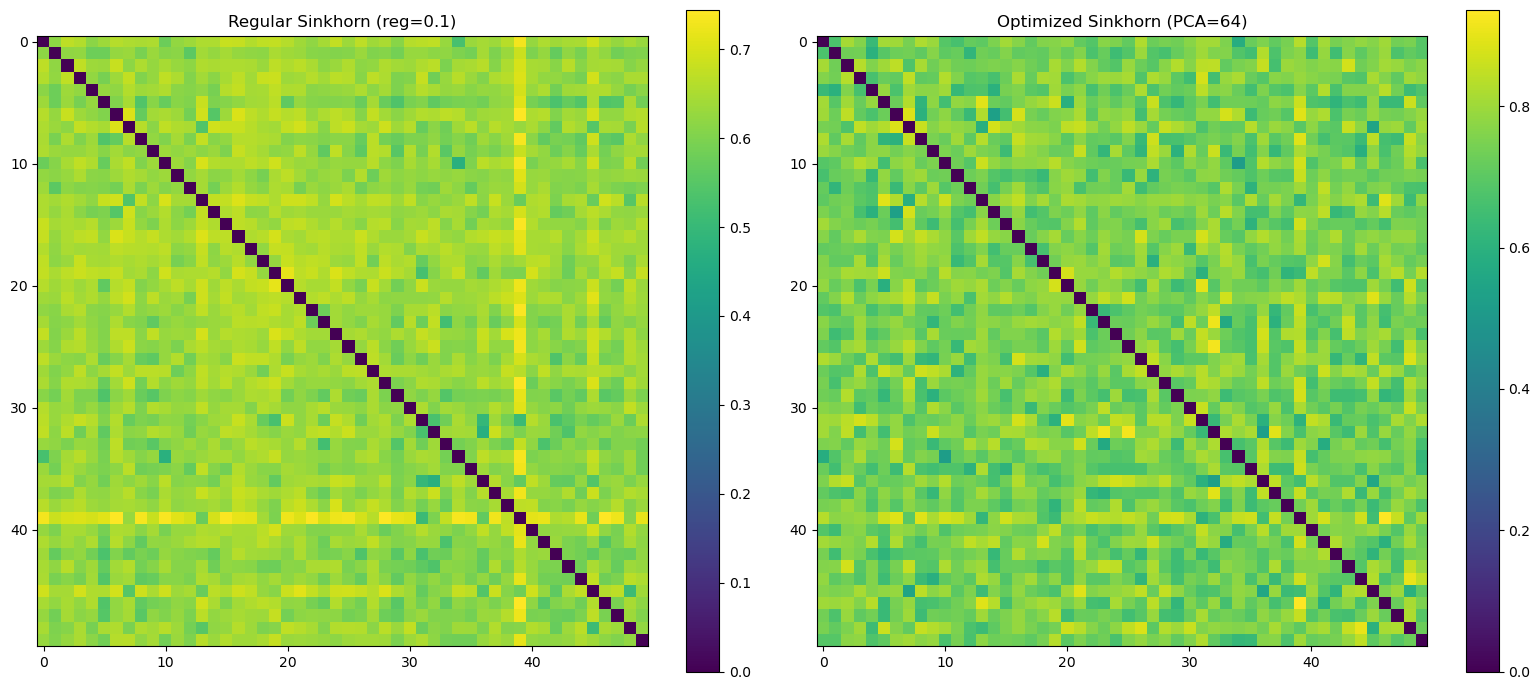

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

sample_size = min(50, n)
sample_idx = np.random.choice(n, size=sample_size, replace=False)

im1 = ax1.imshow(distances_sinkhorn[sample_idx][:, sample_idx], cmap='viridis')
ax1.set_title('Regular Sinkhorn (reg=0.1)')
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(distances_optimized[sample_idx][:, sample_idx], cmap='viridis')
ax2.set_title('Optimized Sinkhorn (PCA=64)')
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

## 4. Topological Data Analysis

Now let's use both distance matrices for persistent homology to detect topological features.

In [ ]:
def compute_and_plot_persistence(distance_matrix, title, max_dim=1, max_edges=None):
    rips = Rips(maxdim=max_dim, verbose=False)
    diagrams = rips.fit_transform(distance_matrix, distance_matrix=True)
    
    fig, ax = plt.subplots(figsize=(10, 7))
    plot_diagrams(diagrams, title=title, ax=ax)
    plt.tight_layout()
    plt.show()
    
    return diagrams

In [ ]:
tda_sample_size = min(100, n) 
tda_sample_idx = np.random.choice(n, size=tda_sample_size, replace=False)

distances_sinkhorn_sample = distances_sinkhorn[tda_sample_idx][:, tda_sample_idx]
distances_optimized_sample = distances_optimized[tda_sample_idx][:, tda_sample_idx]

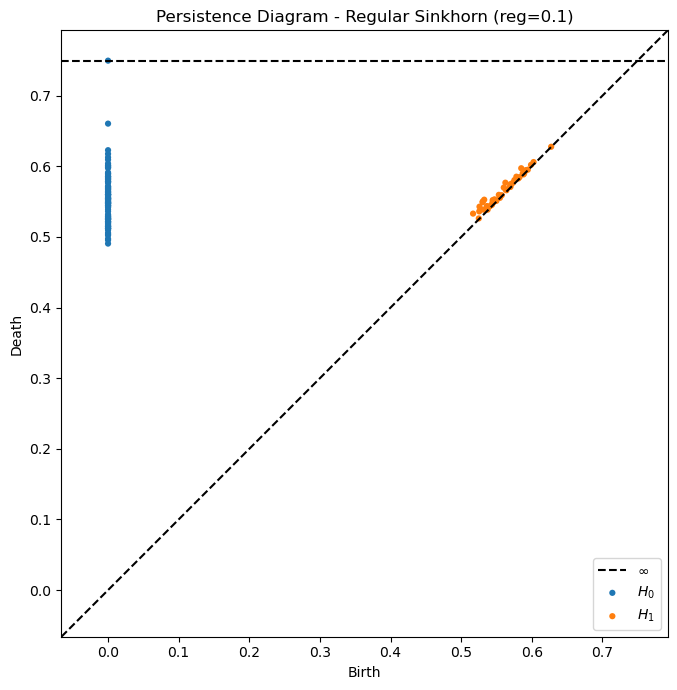

Time to compute persistence diagram: 0.13 seconds


In [ ]:
start_time = time.time()
diagrams_sinkhorn = compute_and_plot_persistence(
    distances_sinkhorn_sample, 
    "Persistence Diagram - Regular Sinkhorn (reg=0.1)",
    max_dim=1
)
print(f"Time to compute persistence diagram: {time.time() - start_time:.2f} seconds")

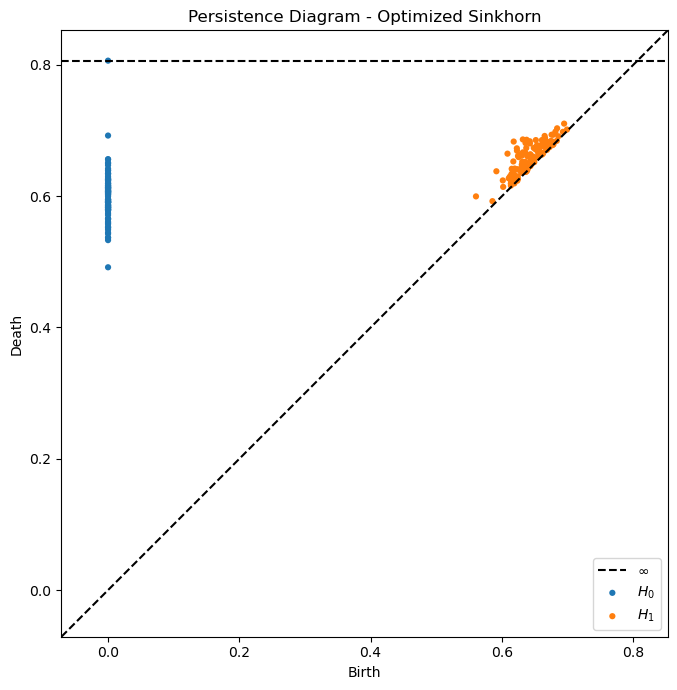

Time to compute persistence diagram: 0.08 seconds


In [ ]:
start_time = time.time()
diagrams_optimized = compute_and_plot_persistence(
    distances_optimized_sample, 
    "Persistence Diagram - Optimized Sinkhorn",
    max_dim=1
)
print(f"Time to compute persistence diagram: {time.time() - start_time:.2f} seconds")

## 5. Compare Persistence Diagrams

Let's check how similar the persistence diagrams are from both methods:

In [ ]:
bottleneck_distances = []
for i in range(min(len(diagrams_sinkhorn), len(diagrams_optimized))):
    bottleneck_dist = persim.bottleneck(diagrams_sinkhorn[i], diagrams_optimized[i])
    bottleneck_distances.append(bottleneck_dist)
    print(f"Bottleneck distance for dimension {i}: {bottleneck_dist:.4f}")

Bottleneck distance for dimension 0: 0.0579
Bottleneck distance for dimension 1: 0.0327


/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/bottleneck.py:55: UserWarning: dgm1 has points with non-finite death times;ignoring those points
  warnings.warn(
/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/bottleneck.py:64: UserWarning: dgm2 has points with non-finite death times;ignoring those points
  warnings.warn(


## 6. Visualize Topological Features

Let's visualize the most significant topological features:

In [ ]:
def extract_significant_features(diagrams, threshold=0.1):
    significant_features = []
    
    for dim, diagram in enumerate(diagrams):
        persistence = diagram[:, 1] - diagram[:, 0]
        
        sig_idx = np.where(persistence > threshold)[0]
        significant = diagram[sig_idx]
        
        if len(significant) > 0:
            significant_features.append((dim, significant))
            
    return significant_features

In [ ]:
significant_sinkhorn = extract_significant_features(diagrams_sinkhorn, threshold=0.1)
significant_optimized = extract_significant_features(diagrams_optimized, threshold=0.1)

print("Significant Topological Features - Regular Sinkhorn:")
for dim, features in significant_sinkhorn:
    print(f"  Dimension {dim}: {len(features)} features")

print("\nSignificant Topological Features - Optimized Sinkhorn:")
for dim, features in significant_optimized:
    print(f"  Dimension {dim}: {len(features)} features")

Significant Topological Features - Regular Sinkhorn:
  Dimension 0: 100 features

Significant Topological Features - Optimized Sinkhorn:
  Dimension 0: 100 features


## 7. Visualize Data in Lower Dimensions with tSNE/UMAP

In [35]:
%pip install umap-learn

  Obtaining dependency information for umap-learn from https://files.pythonhosted.org/packages/3c/8f/671c0e1f2572ba625cbcc1faeba9435e00330c3d6962858711445cf1e817/umap_learn-0.5.7-py3-none-any.whl.metadata
  Obtaining dependency information for pynndescent>=0.5 from https://files.pythonhosted.org/packages/d2/53/d23a97e0a2c690d40b165d1062e2c4ccc796be458a1ce59f6ba030434663/pynndescent-0.5.13-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [36]:
from sklearn.manifold import TSNE
import umap

def get_embedding(distance_matrix, method='tsne', n_components=2):
    if method == 'tsne':
        embedding = TSNE(n_components=n_components, metric='precomputed',
                        init='random', learning_rate='auto').fit_transform(distance_matrix)
    elif method == 'umap':
        embedding = umap.UMAP(n_components=n_components, metric='precomputed').fit_transform(distance_matrix)
    else:
        raise ValueError(f"Unknown embedding method: {method}")
    return embedding

In [ ]:
print("Computing tSNE embedding from regular Sinkhorn distances...")
embedding_sinkhorn = get_embedding(distances_sinkhorn_sample, method='tsne')

print("Computing tSNE embedding from optimized Sinkhorn distances...")
embedding_optimized = get_embedding(distances_optimized_sample, method='tsne')

Computing tSNE embedding from regular Sinkhorn distances...
Computing tSNE embedding from optimized Sinkhorn distances...


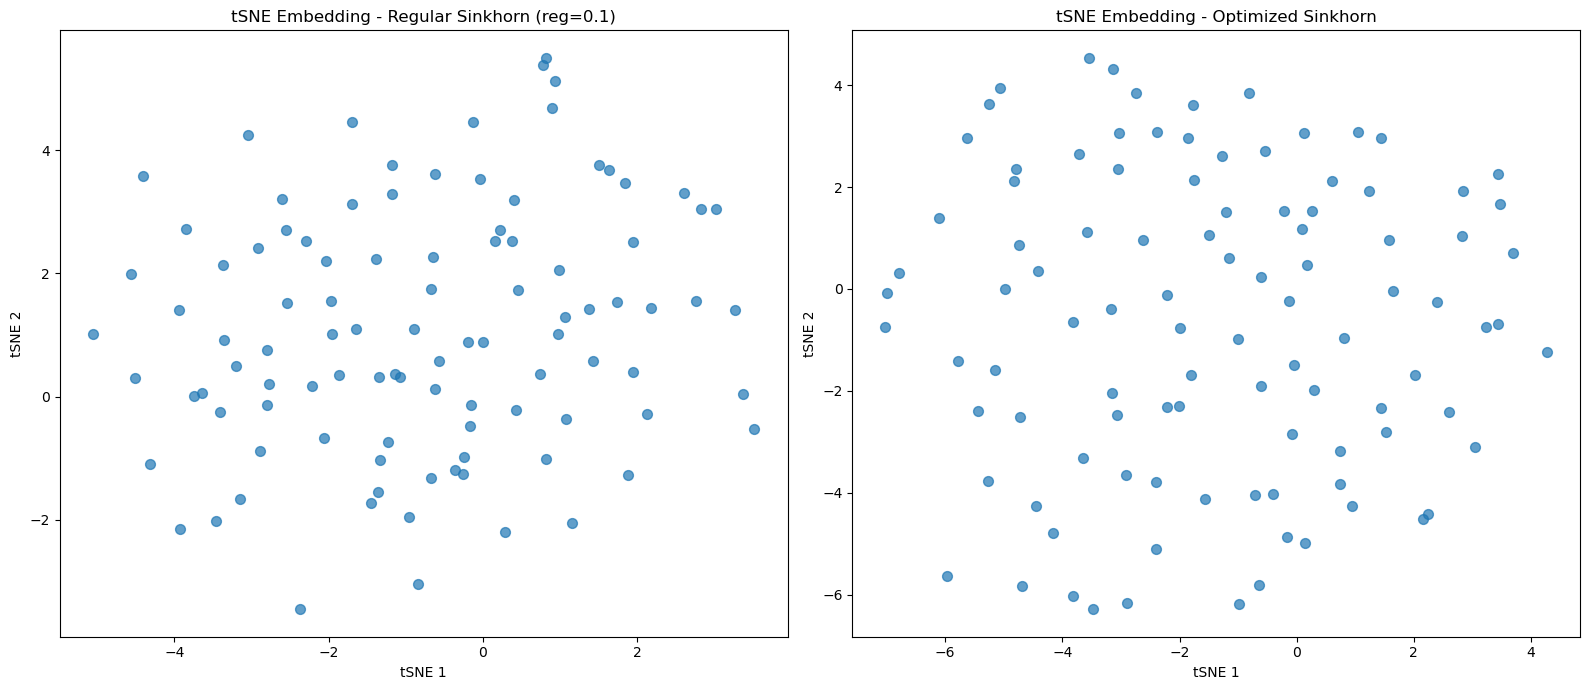

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.scatter(embedding_sinkhorn[:, 0], embedding_sinkhorn[:, 1], s=50, alpha=0.7)
ax1.set_title('tSNE Embedding - Regular Sinkhorn (reg=0.1)')
ax1.set_xlabel('tSNE 1')
ax1.set_ylabel('tSNE 2')

ax2.scatter(embedding_optimized[:, 0], embedding_optimized[:, 1], s=50, alpha=0.7)
ax2.set_title('tSNE Embedding - Optimized Sinkhorn')
ax2.set_xlabel('tSNE 1')
ax2.set_ylabel('tSNE 2')

plt.tight_layout()
plt.show()

In [38]:
# Visualize umap
print("Computing UMAP embedding from regular Sinkhorn distances...")
embedding_sinkhorn_umap = get_embedding(distances_sinkhorn_sample, method='umap')
print("Computing UMAP embedding from optimized Sinkhorn distances...")
embedding_optimized_umap = get_embedding(distances_optimized_sample, method='umap')


Computing UMAP embedding from regular Sinkhorn distances...


AttributeError: module 'umap' has no attribute 'UMAP'